In [25]:
import importlib
import Multiclass_functions_1

import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from Multiclass_functions_1 import * # import all functions
DEVICE = "mps" if torch.mps.is_available() else "cpu"


In [26]:
importlib.reload(Multiclass_functions_1)
from Multiclass_functions_1 import * 

In [27]:
print(DEVICE)

mps


In [28]:
BATCH_SIZE = 32
LR = 1e-3
EPOCH = 20
criterion = nn.CrossEntropyLoss()
new_model_train = True
model_type = "MLP"
dataset = "MNIST"
save_model_path = f'/Volumes/김상현/results/Multiclass_Classification_MNIST/{model_type}_{dataset}.pt'

In [29]:
transform = transforms.ToTensor()
train_DS = datasets.MNIST(root = '/Volumes/김상현/dataset', train = True, download = False, transform = transform)
test_DS = datasets.MNIST(root = '/Volumes/김상현/dataset', train = False, download = False, transform = transform)
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

In [30]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.linear = nn.Sequential(nn.Linear(28 * 28, 100),
                                    nn.ReLU(),
                                    nn.Linear(100, 10))
        
    def forward(self, x):
        x = torch.flatten(x, start_dim=1) # 개 채 행 렬 -> 개 , 행*열
        x = self.linear(x)
        return x

In [31]:
model = MLP().to(DEVICE)
print(model)

MLP(
  (linear): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
)


Epoch: 1, train loss: 0.307
Train Accuaracy: 54884/60000 (91.5%)
--------------------
Epoch: 2, train loss: 0.137
Train Accuaracy: 57603/60000 (96.0%)
--------------------
Epoch: 3, train loss: 0.095
Train Accuaracy: 58329/60000 (97.2%)
--------------------
Epoch: 4, train loss: 0.073
Train Accuaracy: 58668/60000 (97.8%)
--------------------
Epoch: 5, train loss: 0.058
Train Accuaracy: 58923/60000 (98.2%)
--------------------
Epoch: 6, train loss: 0.047
Train Accuaracy: 59149/60000 (98.6%)
--------------------
Epoch: 7, train loss: 0.039
Train Accuaracy: 59280/60000 (98.8%)
--------------------
Epoch: 8, train loss: 0.032
Train Accuaracy: 59442/60000 (99.1%)
--------------------
Epoch: 9, train loss: 0.027
Train Accuaracy: 59502/60000 (99.2%)
--------------------
Epoch: 10, train loss: 0.022
Train Accuaracy: 59580/60000 (99.3%)
--------------------
Epoch: 11, train loss: 0.019
Train Accuaracy: 59667/60000 (99.4%)
--------------------
Epoch: 12, train loss: 0.016
Train Accuaracy: 59706/

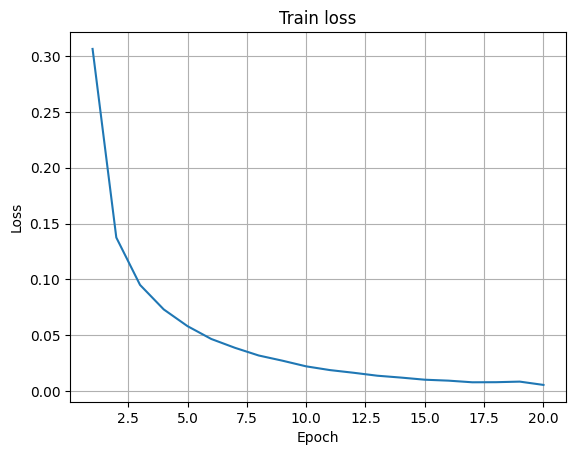

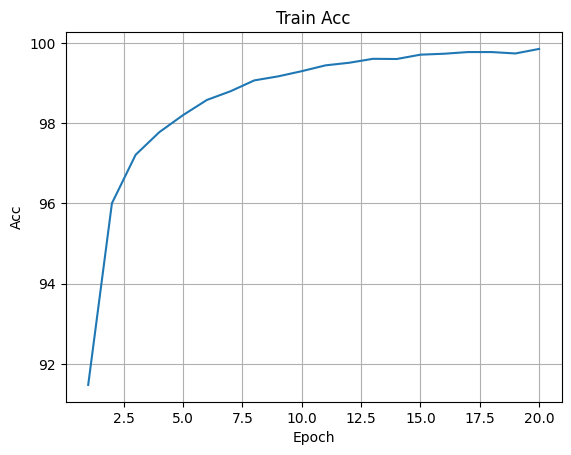

In [32]:
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr = LR)
    loss_history, acc_history = Train(model, train_DL, criterion, optimizer, EPOCH)
    
    torch.save(model, save_model_path)

    plt.plot(range(1, EPOCH + 1), loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title("Train loss")
    plt.grid()
    plt.show()
    
    
    plt.plot(range(1, EPOCH + 1), acc_history)
    plt.xlabel('Epoch')
    plt.ylabel('Acc')
    plt.title('Train Acc')
    plt.grid()
    plt.show()

In [9]:
load_model = torch.load(save_model_path, map_location = DEVICE, weights_only = False)

In [10]:
Test(load_model, test_DL)

Test Accuaracy: 9805/10000 (98.0%)


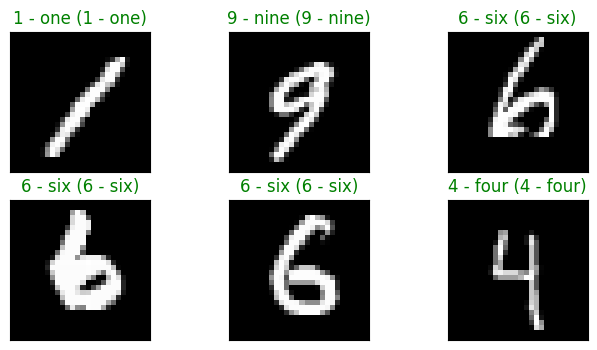

In [11]:
Test_plot(load_model, test_DL)

In [54]:
print(count_params(load_model)) 

79510
